# Predictive Customer Churn Model for a Telecom Company
## Case Study: ConnectTel

## Project Objective

The objective of this project is to develop a machine learning model that can predict whether a telecom customer is likely to churn.

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import shap

print("All libraries are working!")

All libraries are working!


In [ ]:
import pandas as pd

df = pd.read_excel("Dataset/Telco_customer_churn.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2. Load Dataset

In [3]:
import pandas as pd
df = pd.read_excel("Dataset/Telco_customer_churn.xlsx")
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Dataset Overview

In [4]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           704

## 4. Missing Values Analysis

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


## 5. Churn Analysis

In [6]:
print("Churn Count:")
print(df["Churn Label"].value_counts())

Churn Count:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
churn_count = df["Churn Label"].value_counts()

print("Churn Percentage:")
print((churn_count / len(df)) * 100)

Churn Percentage:
Churn Label
No     73.463013
Yes    26.536987
Name: count, dtype: float64


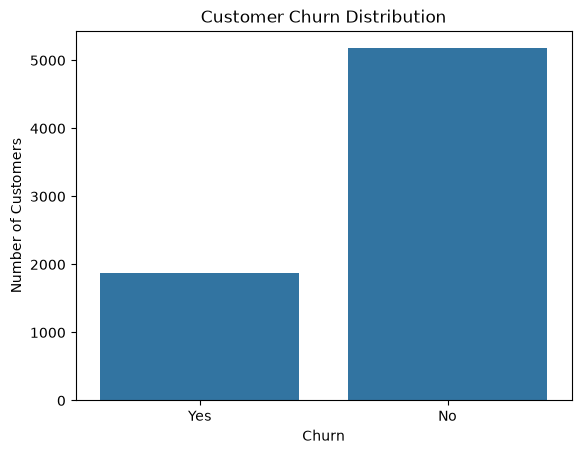

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Churn Label")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## 6. Exploratory Data Analysis

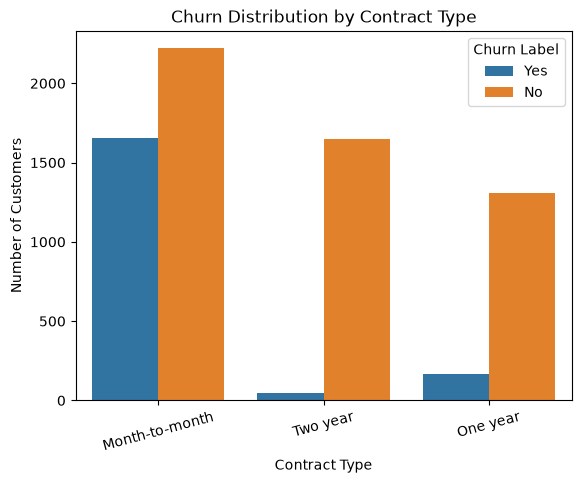

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn Label")

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

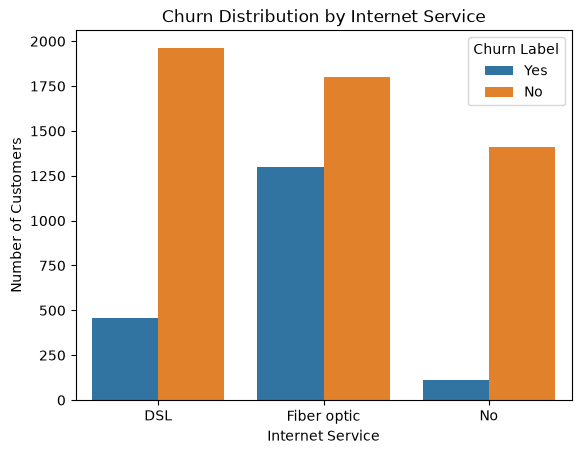

In [ ]:
sns.countplot(data=df, x="Internet Service", hue="Churn Label")

plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

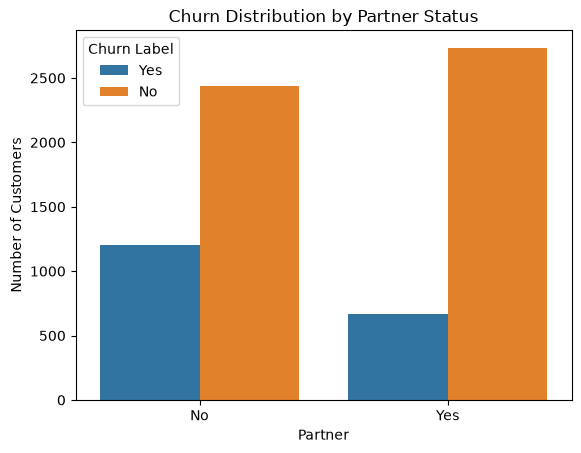

In [ ]:
sns.countplot(data=df, x="Partner", hue="Churn Label")

plt.title("Churn Distribution by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

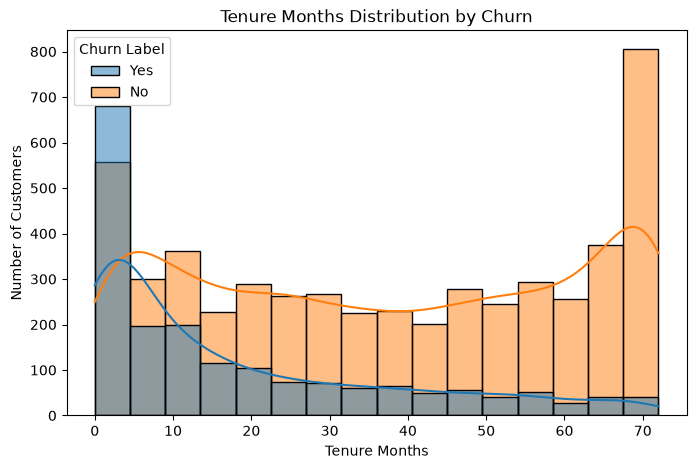

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Tenure Months", hue="Churn Label", kde=True)

plt.title("Tenure Months Distribution by Churn")
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")
plt.show()

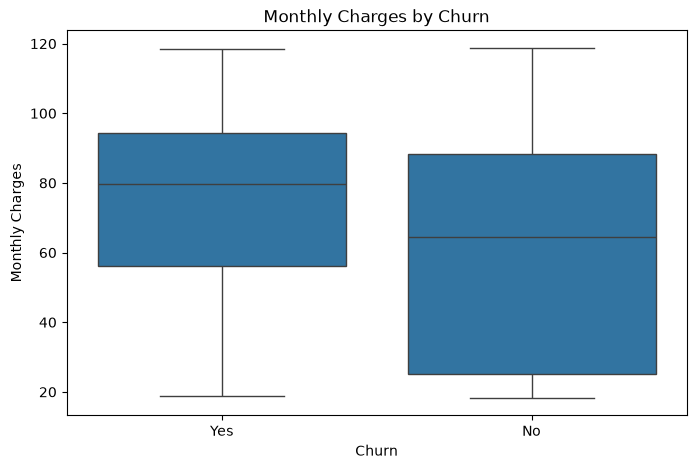

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn Label", y="Monthly Charges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## 7. Feature Engineering

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

df["TotalChargesPerTenure"] = df["Total Charges"] / (df["Tenure Months"] + 1)

print(df[["Total Charges", "Tenure Months", "TotalChargesPerTenure"]].head())

   Total Charges  Tenure Months  TotalChargesPerTenure
0         108.15              2              36.050000
1         151.65              2              50.550000
2         820.50              8              91.166667
3        3046.05             28             105.036207
4        5036.30             49             100.726000


In [ ]:
service_cols = [
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df["ServiceCount"] = (
    (df["Phone Service"] == "Yes").astype(int)
    + (df["Multiple Lines"] == "Yes").astype(int)
    + (df["Internet Service"] != "No").astype(int)
    + (df["Online Security"] == "Yes").astype(int)
    + (df["Online Backup"] == "Yes").astype(int)
    + (df["Device Protection"] == "Yes").astype(int)
    + (df["Tech Support"] == "Yes").astype(int)
    + (df["Streaming TV"] == "Yes").astype(int)
    + (df["Streaming Movies"] == "Yes").astype(int)
)

print(df[["CustomerID", "ServiceCount"]].head())

   CustomerID  ServiceCount
0  3668-QPYBK             4
1  9237-HQITU             2
2  9305-CDSKC             6
3  7892-POOKP             7
4  0280-XJGEX             7


In [ ]:
df["TenureGroup"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=["0-12", "13-24", "25-48", "49-60", "61-72"]
)

print(df[["Tenure Months", "TenureGroup"]].head())

   Tenure Months TenureGroup
0              2        0-12
1              2        0-12
2              8        0-12
3             28       25-48
4             49       49-60


## 8. Data Preprocessing

In [ ]:
y = df["Churn Label"]
X = df.drop(columns=[
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "CLTV"
])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 22)
Target shape: (7043,)


In [ ]:
from sklearn.model_selection import train_test_split

# Convert churn labels into 0 and 1
y = df["Churn Label"].map({"No": 0, "Yes": 1})

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 22)
Testing features: (1409, 22)
Training target: (5634,)
Testing target: (1409,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "TotalChargesPerTenure",
    "ServiceCount"
]

categorical_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "TenureGroup"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 53)
Processed testing data shape: (1409, 53)


## 9. Model Training and Evaluation

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce").fillna(0)

df["TotalChargesPerTenure"] = (
    df["Total Charges"] / (df["Tenure Months"] + 1)
)

print("Missing Total Charges:", df["Total Charges"].isnull().sum())
print(df[["Total Charges", "Tenure Months", "TotalChargesPerTenure"]].head())

Missing Total Charges: 0
   Total Charges  Tenure Months  TotalChargesPerTenure
0         108.15              2              36.050000
1         151.65              2              50.550000
2         820.50              8              91.166667
3        3046.05             28             105.036207
4        5036.30             49             100.726000


In [ ]:
y = df["Churn Label"].map({"No": 0, "Yes": 1})

X = df.drop(columns=[
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "CLTV"
])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 22)
Target shape: (7043,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (5634, 22)
Testing features: (1409, 22)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "TotalChargesPerTenure",
    "ServiceCount"
]

categorical_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "TenureGroup"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 53)
Processed testing data shape: (1409, 53)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

y_pred = logistic_model.predict(X_test_processed)
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))

Precision: 0.5222816399286988
Recall: 0.7834224598930482
AUC-ROC: 0.8522901650778889


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
rf_pred = random_forest_model.predict(X_test_processed)
rf_prob = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("AUC-ROC:", roc_auc_score(y_test, rf_prob))

Precision: 0.5593607305936074
Recall: 0.6550802139037433
AUC-ROC: 0.8319421839882198


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
xgb_pred = xgb_model.predict(X_test_processed)
xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("AUC-ROC:", roc_auc_score(y_test, xgb_prob))

Precision: 0.6634615384615384
Recall: 0.553475935828877
AUC-ROC: 0.8545441628561834


## 10. Cross-Validation and Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import cross_val_score

logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression 5-Fold AUC-ROC Scores:")
print(logistic_cv_scores)

print("Mean AUC-ROC:", logistic_cv_scores.mean())

Logistic Regression 5-Fold AUC-ROC Scores:
[0.87435574 0.86944404 0.86627325 0.85556525 0.83902205]
Mean AUC-ROC: 0.8609320663029034


In [ ]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Random Forest 5-Fold AUC-ROC Scores:")
print(rf_cv_scores)

print("Mean AUC-ROC:", rf_cv_scores.mean())

Random Forest 5-Fold AUC-ROC Scores:
[0.85657506 0.85327905 0.8422984  0.83073005 0.83107739]
Mean AUC-ROC: 0.8427919895143765


In [ ]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("XGBoost 5-Fold AUC-ROC Scores:")
print(xgb_cv_scores)

print("Mean AUC-ROC:", xgb_cv_scores.mean())

XGBoost 5-Fold AUC-ROC Scores:
[0.87655914 0.86875737 0.86184019 0.85096053 0.84019889]
Mean AUC-ROC: 0.8596632248137563


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation AUC-ROC:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}

Best Cross-Validation AUC-ROC:
0.8641665837166871


In [ ]:
best_xgb_model = grid_search.best_estimator_

tuned_xgb_pred = best_xgb_model.predict(X_test_processed)
tuned_xgb_prob = best_xgb_model.predict_proba(X_test_processed)[:, 1]

print("Tuned XGBoost Performance:")
print("Precision:", precision_score(y_test, tuned_xgb_pred))
print("Recall:", recall_score(y_test, tuned_xgb_pred))
print("AUC-ROC:", roc_auc_score(y_test, tuned_xgb_prob))


Tuned XGBoost Performance:
Precision: 0.6722408026755853
Recall: 0.5374331550802139
AUC-ROC: 0.8569996641607895


## 11. Final Model Evaluation

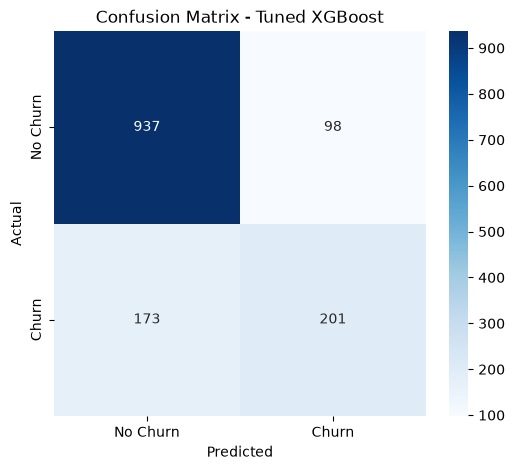

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tuned_xgb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

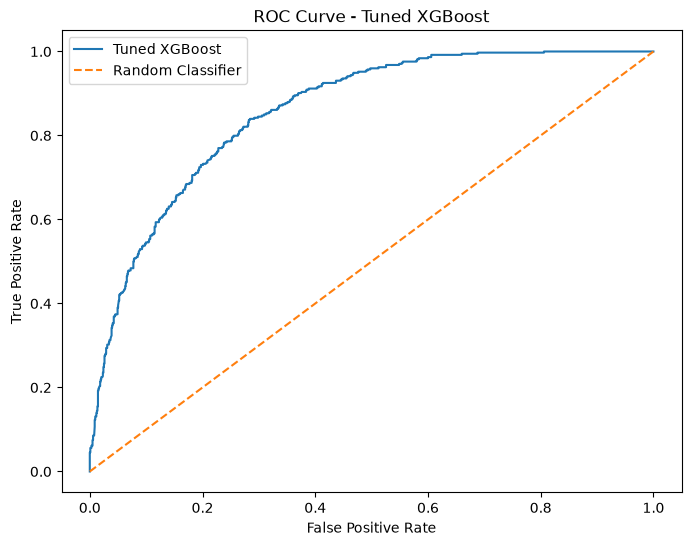

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, tuned_xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label="Tuned XGBoost")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Tuned XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Precision": [
        0.5223,
        0.5594,
        0.6635,
        0.6722
    ],
    "Recall": [
        0.7834,
        0.6551,
        0.5535,
        0.5374
    ],
    "AUC-ROC": [
        0.8523,
        0.8319,
        0.8545,
        0.8570
    ]
})

model_results

,Model,Precision,Recall,AUC-ROC
0,Logistic Regression,0.5223,0.7834,0.8523
1,Random Forest,0.5594,0.6551,0.8319
2,XGBoost,0.6635,0.5535,0.8545
3,Tuned XGBoost,0.6722,0.5374,0.8570


## 12. SHAP Analysis

In [ ]:
import shap

feature_names = preprocessor.get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

explainer = shap.TreeExplainer(best_xgb_model)

shap_values = explainer.shap_values(X_test_shap)

print("SHAP analysis completed successfully!")

SHAP analysis completed successfully!


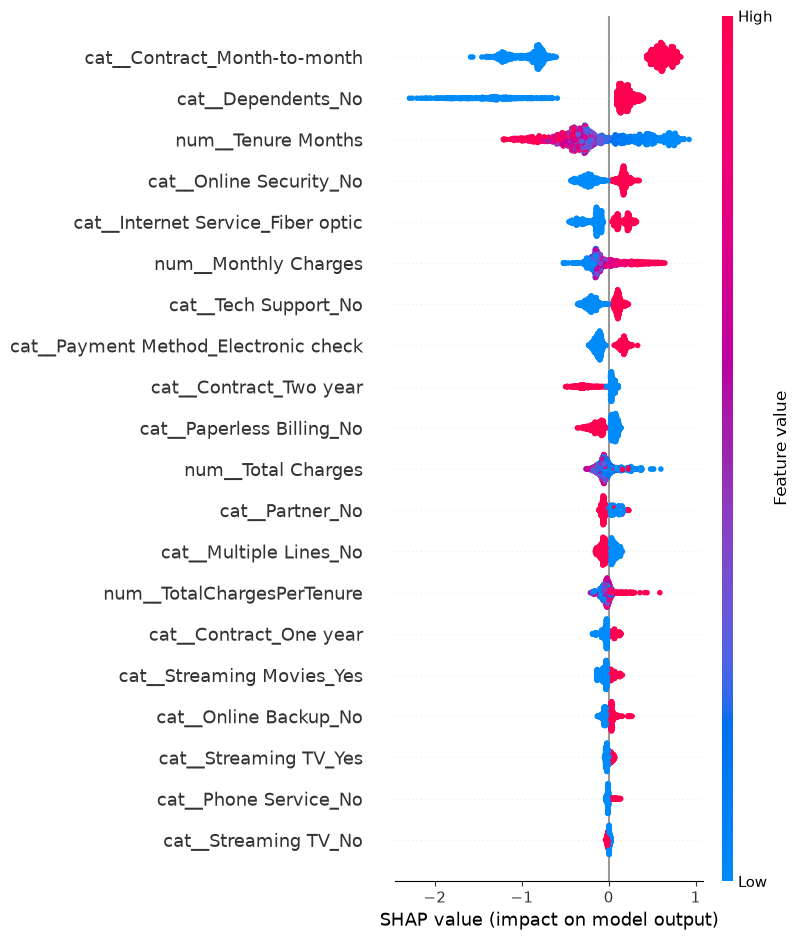

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    show=True
)

In [ ]:
import numpy as np

shap_importance = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean Absolute SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print("Top 10 Features Influencing Churn:")
print(shap_importance.head(10).to_string(index=False))

Top 10 Features Influencing Churn:
                             Feature  Mean Absolute SHAP
        cat__Contract_Month-to-month            0.767720
                  cat__Dependents_No            0.463024
                  num__Tenure Months            0.425676
             cat__Online Security_No            0.205351
   cat__Internet Service_Fiber optic            0.192362
                num__Monthly Charges            0.175273
                cat__Tech Support_No            0.153371
cat__Payment Method_Electronic check            0.140326
              cat__Contract_Two year            0.103377
           cat__Paperless Billing_No            0.094155


In [ ]:
shap_direction = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean SHAP": shap_values.mean(axis=0),
    "Mean Absolute SHAP": np.abs(shap_values).mean(axis=0)
})

shap_direction = shap_direction.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print("Top 10 SHAP Features with Direction:")
print(shap_direction.head(10).to_string(index=False))

Top 10 SHAP Features with Direction:
                             Feature  Mean SHAP  Mean Absolute SHAP
        cat__Contract_Month-to-month  -0.088005            0.767720
                  cat__Dependents_No  -0.155875            0.463024
                  num__Tenure Months  -0.136617            0.425676
             cat__Online Security_No  -0.035910            0.205351
   cat__Internet Service_Fiber optic  -0.035888            0.192362
                num__Monthly Charges  -0.033583            0.175273
                cat__Tech Support_No  -0.043726            0.153371
cat__Payment Method_Electronic check  -0.026358            0.140326
              cat__Contract_Two year  -0.034025            0.103377
           cat__Paperless Billing_No  -0.014957            0.094155


In [ ]:

selected_features = [
    "cat__Contract_Month-to-month",
    "cat__Dependents_No",
    "cat__Online Security_No",
    "cat__Internet Service_Fiber optic",
    "cat__Tech Support_No",
    "cat__Payment Method_Electronic check",
    "cat__Contract_Two year",
    "cat__Paperless Billing_No"
]

for feature in selected_features:
    feature_index = X_test_shap.columns.get_loc(feature)
    feature_values = X_test_shap[feature].values
    feature_shap = shap_values[:, feature_index]

    print("\n", feature)
    print("Mean SHAP when feature = 1:",
          feature_shap[feature_values == 1].mean())
    print("Mean SHAP when feature = 0:",
          feature_shap[feature_values == 0].mean())


 cat__Contract_Month-to-month
Mean SHAP when feature = 1: 0.61948186
Mean SHAP when feature = 0: -0.94789016

 cat__Dependents_No
Mean SHAP when feature = 1: 0.19980358
Mean SHAP when feature = 0: -1.3374683

 cat__Online Security_No
Mean SHAP when feature = 1: 0.17028645
Mean SHAP when feature = 0: -0.24006774

 cat__Internet Service_Fiber optic
Mean SHAP when feature = 1: 0.1798307
Mean SHAP when feature = 0: -0.20201226

 cat__Tech Support_No
Mean SHAP when feature = 1: 0.10999611
Mean SHAP when feature = 0: -0.19636102

 cat__Payment Method_Electronic check
Mean SHAP when feature = 1: 0.1693891
Mean SHAP when feature = 0: -0.12559168

 cat__Contract_Two year
Mean SHAP when feature = 1: -0.28758705
Mean SHAP when feature = 0: 0.045375038

 cat__Paperless Billing_No
Mean SHAP when feature = 1: -0.13509549
Mean SHAP when feature = 0: 0.06642225


## Business Insights

Based on the exploratory data analysis and SHAP analysis, the model identified several customer characteristics that were strongly associated with churn predictions.

1. Month-to-month contract was the most influential feature in the model. Customers with month-to-month contracts received positive SHAP contributions toward churn prediction.

2. Customers without dependents were associated with higher churn predictions.

3. Lack of online security and lack of technical support showed positive contributions toward churn prediction.

4. Fiber optic internet service was associated with higher churn predictions in the model.

5. Electronic check payment method showed a positive contribution toward churn prediction.

6. Two-year contract was associated with a negative SHAP contribution toward churn prediction.

7. The analysis also indicates that customer tenure and monthly charges are important numerical factors in churn prediction.

## Actionable Recommendations

Based on the model findings, ConnectTel can consider the following actions:

1. Provide retention offers or flexible plans for customers on month-to-month contracts.

2. Identify customers with short tenure and provide onboarding support and engagement offers.

3. Consider additional support or security benefits for customers without online security or technical support services.

4. Monitor customers using fiber optic internet and investigate service quality, pricing, and customer experience.

5. Encourage customers to use automatic payment methods through suitable benefits or incentives.

6. Promote longer-term contracts by providing suitable plans, discounts, or additional services.

7. Use the churn prediction model to identify high-risk customers early and target them with personalized retention campaigns.

## Final Conclusion

This project developed a machine learning based customer churn prediction system for ConnectTel.

The dataset was analyzed through exploratory data analysis and relevant features were created using feature engineering. Categorical variables were encoded and numerical variables were scaled before model training.

Logistic Regression, Random Forest, and XGBoost models were trained and evaluated using Precision, Recall, and AUC-ROC. Cross-validation and GridSearchCV were also used to improve the modeling process.

SHAP analysis was used to interpret the model and identify the features that had the greatest influence on churn predictions.

The developed approach can help ConnectTel identify customers who may be at higher risk of churn and support data-driven customer retention strategies.